In [1]:
_repo_root = !git rev-parse --show-toplevel
%cd -q {_repo_root[0]}
del _repo_root

# HIGGS feature-sensitivity bounds

Publication figures for the empirical deviation ratios of trained HIGGS spectral neurons.

## Setup

In [2]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from paper.experiments.higgs_robustness import (
    default_result_path,
    validate_results,
)
from paper.experiments.higgs_scaling import PROFILES
from paper.plotting import plot_higgs_deviation_shell_grid

mpl.rcParams.update({
    "figure.dpi": 140,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [3]:
profile_name = "full"
noise_level = 0.5
shell_count = 4
feature_row_height_mm = 12.0
profile = PROFILES[profile_name]
result_path = default_result_path(profile_name, noise_level)
plot_dir = Path("plots")

## Method

The experiment stores a fine joint histogram over perturbation magnitude and deviation ratio. The figure merges adjacent magnitude bins into disjoint shells, normalizes within each trained model and shell, and then gives every model equal weight. Each feature-by-shell cell plots the resulting bin probabilities directly and chooses its own y-axis limit; dimensions within a cell share that limit. The ratio range is `[0, 1]`; ratios above the theoretical bound are not clipped and remain visible in the diagnostics below.

## Load and validate results

In [4]:
if not result_path.exists():
    raise FileNotFoundError(
        f"{result_path} does not exist; run paper.experiments.higgs_robustness first"
    )

results = pd.read_csv(result_path)
validate_results(results, profile, noise_level=noise_level)
print(result_path)

notebooks/runs/higgs_robustness_full_noise_0p5_repeated_shuffle.csv.zst


## Bound diagnostics

In [5]:
histogram_columns = [
    "dim", "data_seed", "init_seed", "perturbation_seed",
    "noise_level", "feature_index", "magnitude_bin_index",
    "total_count",
    "zero_bound_count", "above_bound_count", "max_ratio",
]
histograms = results[histogram_columns]
diagnostics = (
    histograms.groupby(["noise_level", "dim"], as_index=False)
    .agg(
        histogram_cells=("magnitude_bin_index", "size"),
        total_ratios=("total_count", "sum"),
        zero_bounds=("zero_bound_count", "sum"),
        above_bound=("above_bound_count", "sum"),
        max_ratio=("max_ratio", "max"),
    )
)
diagnostics

,noise_level,dim,histogram_cells,total_ratios,zero_bounds,above_bound,max_ratio
0,0.5,3,10752,336000000,0,0,1.000000
1,0.5,7,10752,336000000,0,0,0.999362
2,0.5,11,10752,336000000,0,0,0.982685


## Deviation-ratio distributions

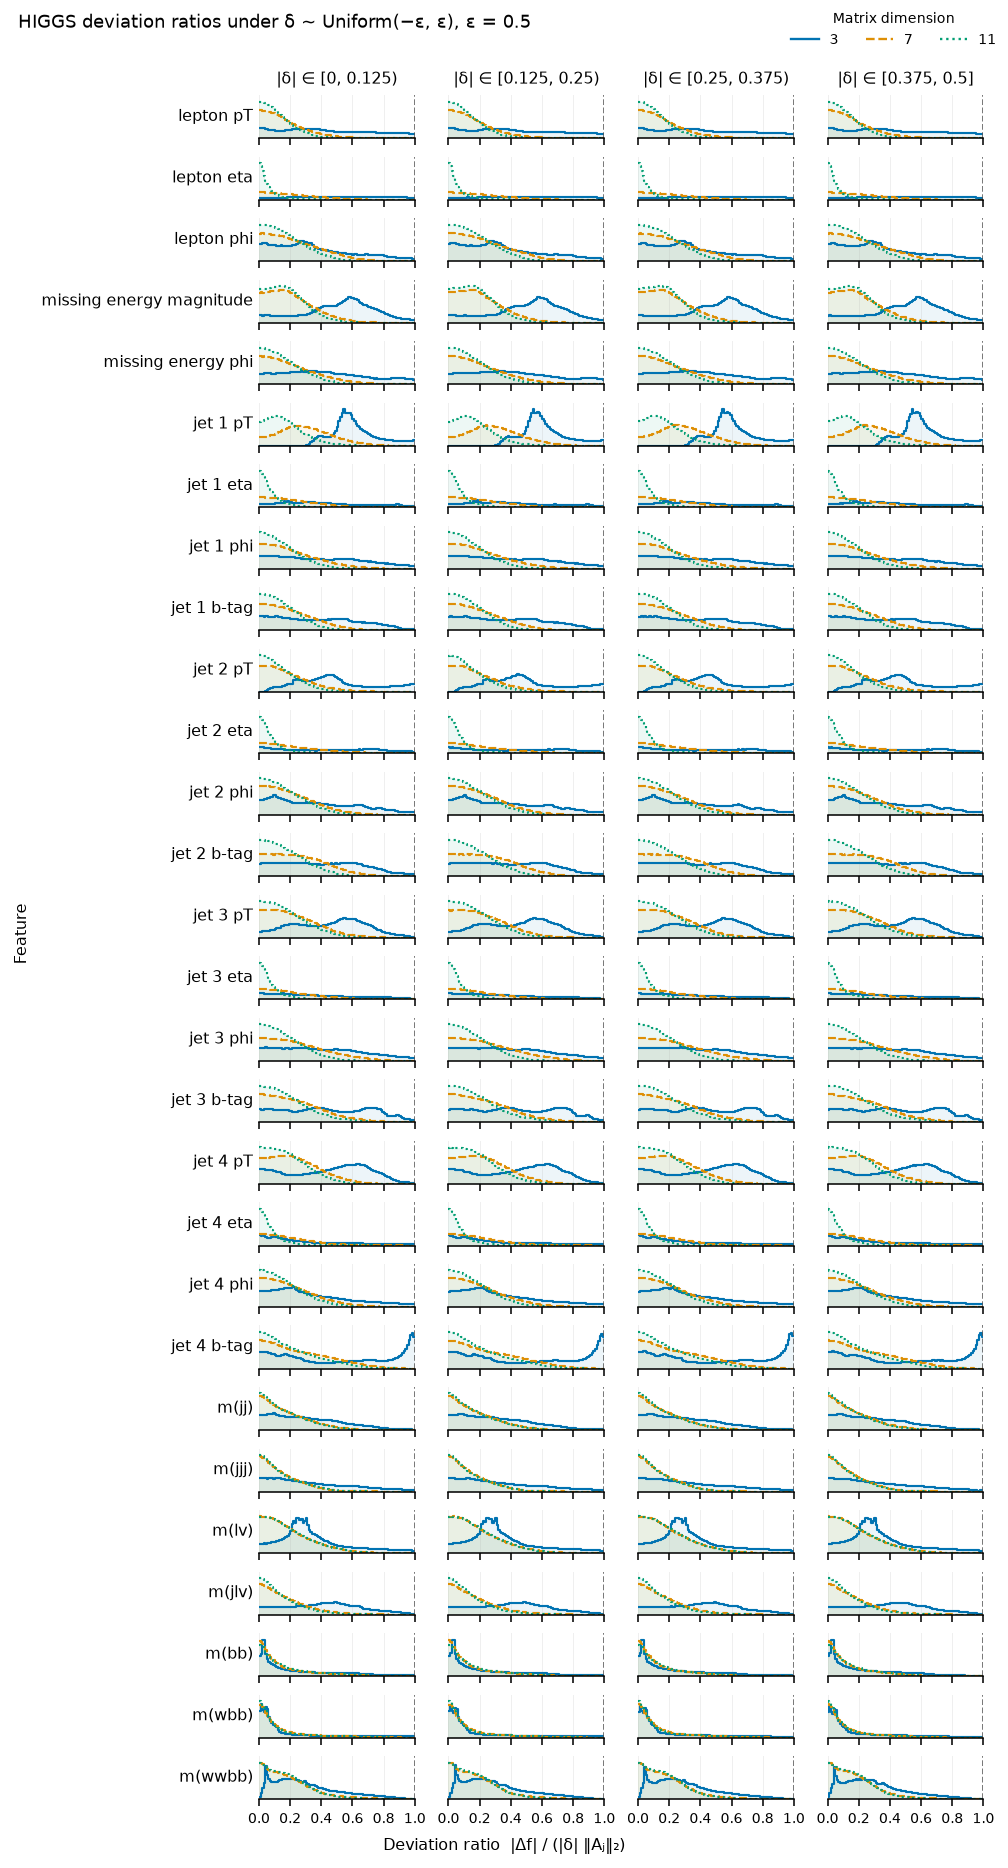

In [6]:
plot_dir.mkdir(parents=True, exist_ok=True)
figure = plot_higgs_deviation_shell_grid(
    results,
    shell_count=shell_count,
    feature_row_height_mm=feature_row_height_mm,
)
noise_label = f"{noise_level:g}".replace(".", "p")
stem = plot_dir / (
    f"higgs_robustness_{profile_name}_noise_{noise_label}_shells_{shell_count}"
)
figure.savefig(
    f"{stem}.pdf", bbox_inches="tight", metadata={"CreationDate": None}
)
figure.savefig(f"{stem}.png", dpi=300, bbox_inches="tight")
display(figure)
plt.close(figure)